In [2]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: An error occurred during the signature verification. The repository is not updated and the previous index files will be used. GPG error: https://cli.github.com/packages stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://cli.github.com/packages/dists/stable/InRelease  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Some index files failed to download. They have been ignored, or old ones used instead.
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-do

In [3]:
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)


/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.12/dist-packages/ase/__init__.py


In [4]:
from ase.calculators.espresso import EspressoProfile
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.visualize.plot import plot_atoms
from ase.calculators.espresso import Espresso
from ase.eos import EquationOfState

plt.rcParams['figure.dpi'] = 110


In [6]:
!mkdir -p pseudo
!wget -q -O gbrv.tar.gz https://www.physics.rutgers.edu/gbrv/all_pbe_UPF_v1.5.tar.gz
!tar -xzf gbrv.tar.gz -C pseudo

import glob, os, shutil

for f in glob.glob('pseudo/*_*.UPF'):
    new_name = os.path.basename(f).split('_')[0].capitalize() + '.UPF'
    shutil.move(f, os.path.join('pseudo', new_name))

# We only actually need a few elements here: Si
print(sorted(glob.glob('pseudo/*.UPF'))[:10], '...')


['pseudo/Ag.UPF', 'pseudo/Al.UPF', 'pseudo/As.UPF', 'pseudo/Au.UPF', 'pseudo/B.UPF', 'pseudo/Ba.UPF', 'pseudo/Be.UPF', 'pseudo/Bi.UPF', 'pseudo/Br.UPF', 'pseudo/C.UPF'] ...


In [7]:
def pseudo_filename(symbol):
    return f'{symbol}.UPF'

def recommended_cutoffs(symbol):
    """GBRV is designed around one uniform cutoff rather than per-element
    values: ~40 Ry for ecutwfc, and since these are ultrasoft
    pseudopotentials, ecutrho should be 8-12x that (we use 8x)."""
    return 40, 320


**Repeat the full workflow (convergence, EOS, band structure, quantitative gap) for the below materials, and compare the nature of bandgap.**

**Germanium — same diamond-cubic structure family as Si (bulk('Ge', 'diamond', a=5.66)), also an indirect-gap semiconductor, but with a much smaller experimental gap (~0.67 eV). How is Ge bandgap compared to that of Si?**

In [8]:
pseudopotentials_ge = {'Ge': pseudo_filename('Ge')}

Primitive cell:    2 atom(s)
Conventional cell: 8 atom(s)
2x2x2 supercell:   16 atom(s)


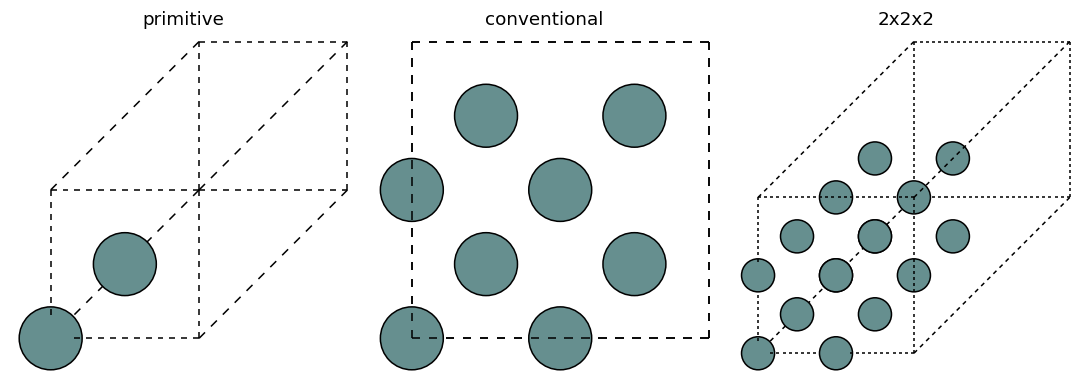

In [ ]:
#visualize
prim = bulk('Ge', 'diamond', a=5.66)
conv = bulk('Ge', 'diamond', a=5.66, cubic=True)
sc222 = prim.repeat((2, 2, 2))

print(f'Primitive cell:    {len(prim)} atom(s)')
print(f'Conventional cell: {len(conv)} atom(s)')
print(f'2x2x2 supercell:   {len(sc222)} atom(s)')

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, atoms) in zip(axes, [('primitive', prim), ('conventional', conv), ('2x2x2', sc222)]):
    plot_atoms(atoms, ax, radii=0.5, show_unit_cell=2)
    ax.set_title(name)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [9]:
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,
        'ecutrho': 200,
        'occupations': 'fixed',
    },
    'electrons': {'conv_thr': 1.0e-8},
}

In [ ]:
#plane wave cutoff
ecut_values = [15, 20, 25, 30, 35, 40, 45, 50]  # Ry
ecut_energies_ge = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('Ge', 'diamond', a=5.66)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_ge, input_data=d, kpts=(4, 4, 4))
    ecut_energies_ge.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies_ge[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -2847.66314 eV/atom
ecutwfc =  20 Ry   E = -2896.61375 eV/atom
ecutwfc =  25 Ry   E = -2904.94005 eV/atom
ecutwfc =  30 Ry   E = -2906.50430 eV/atom
ecutwfc =  35 Ry   E = -2906.71169 eV/atom
ecutwfc =  40 Ry   E = -2906.72175 eV/atom
ecutwfc =  45 Ry   E = -2906.72377 eV/atom
ecutwfc =  50 Ry   E = -2906.72708 eV/atom


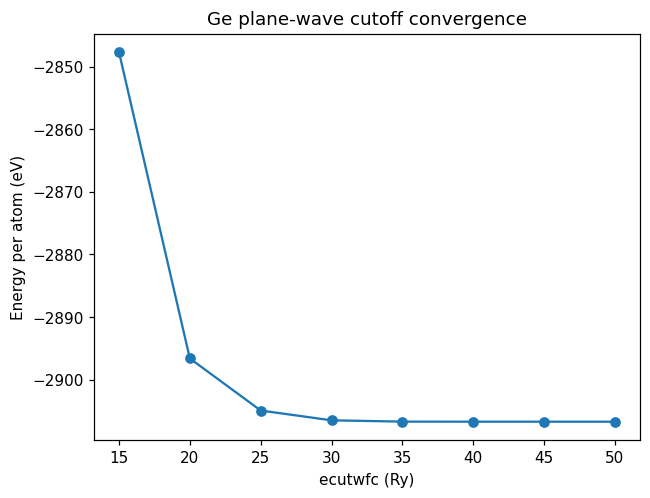

In [ ]:
plt.plot(ecut_values, ecut_energies_ge, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Ge plane-wave cutoff convergence')
plt.show()


In [10]:
converged_ecutwfc_ge = 30

In [ ]:
#KPOINT convergence

In [ ]:
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14]
kpt_energies_ge = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc_ge
    d['system']['ecutrho'] = 8 * converged_ecutwfc_ge
    a = bulk('Ge', 'diamond', a=5.66)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_ge, input_data=d, kpts=(n, n, n))
    kpt_energies_ge.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies_ge[-1]:.5f} eV/atom')


2x2x2 k-mesh   E = -2905.18275 eV/atom
3x3x3 k-mesh   E = -2906.25657 eV/atom
4x4x4 k-mesh   E = -2906.50430 eV/atom
5x5x5 k-mesh   E = -2906.58267 eV/atom
6x6x6 k-mesh   E = -2906.61501 eV/atom
8x8x8 k-mesh   E = -2906.63119 eV/atom
10x10x10 k-mesh   E = -2906.63375 eV/atom
12x12x12 k-mesh   E = -2906.63528 eV/atom
14x14x14 k-mesh   E = -2906.63562 eV/atom


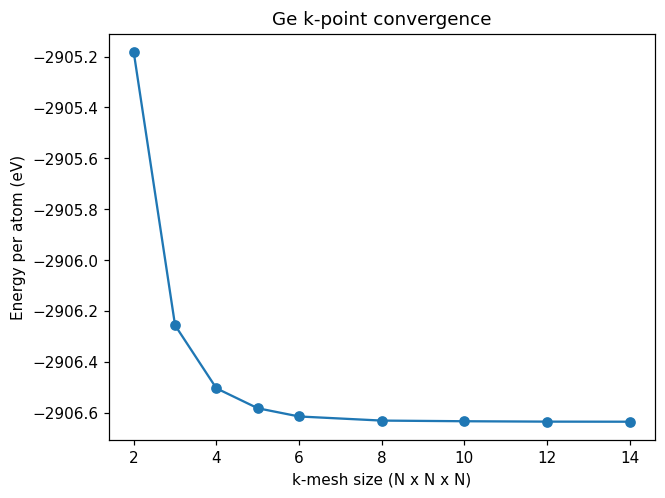

In [ ]:
plt.plot(kgrids, kpt_energies_ge, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('Ge k-point convergence')
plt.show()

In [11]:
converged_kpts_ge = 8

In [ ]:
#EOS
scale_factors = np.linspace(0.94, 1.06, 7)
volumes_ge, eos_energies_ge = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc_ge
d['system']['ecutrho'] = 8 * converged_ecutwfc_ge

for s in scale_factors:
    a = bulk('Ge', 'diamond', a=5.66 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_ge, input_data=d,
                       kpts=(converged_kpts_ge, converged_kpts_ge, converged_kpts_ge))
    volumes_ge.append(a.get_volume())
    eos_energies_ge.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes_ge[-1]:.2f} A^3   E = {eos_energies_ge[-1]:.4f} eV')


a scale = 0.940   V = 37.65 A^3   E = -5812.6674 eV
a scale = 0.960   V = 40.11 A^3   E = -5812.9704 eV
a scale = 0.980   V = 42.66 A^3   E = -5813.1643 eV
a scale = 1.000   V = 45.33 A^3   E = -5813.2624 eV
a scale = 1.020   V = 48.10 A^3   E = -5813.2851 eV
a scale = 1.040   V = 50.99 A^3   E = -5813.2454 eV
a scale = 1.060   V = 53.99 A^3   E = -5813.1667 eV


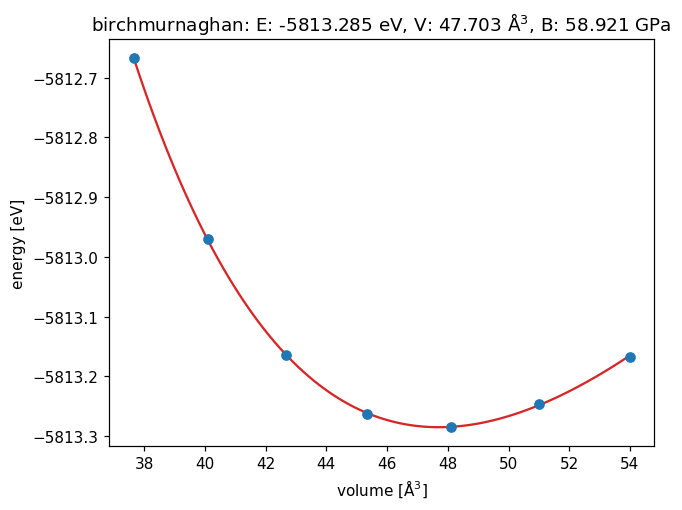

Equilibrium volume: 47.70 A^3, Lattice para: 5.76 A per primitive cell
Bulk modulus B0: 58.9 GPa


In [ ]:
eos = EquationOfState(volumes_ge, eos_energies_ge, eos='birchmurnaghan')
v0, e0, B = eos.fit()
a0 = (v0 * 4) ** (1 / 3)   # diamond-cubic: 8 atoms per conventional cell, 2 per primitive
B_GPa = B / 6.242e-3   # eV/A^3 -> GPa

eos.plot()
plt.show()
print(f'Equilibrium volume: {v0:.2f} A^3, Lattice para: {a0:.2f} A per primitive cell')
print(f'Bulk modulus B0: {B_GPa:.1f} GPa')

In [12]:
a0 = 5.76

In [ ]:
#Band Structure
a_eq = bulk('Ge', 'diamond', a=a0)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc_ge
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc_ge
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_ge, input_data=scf_data,
                      kpts=(converged_kpts_ge, converged_kpts_ge, converged_kpts_ge))
a_eq.get_potential_energy()

-5813.2798704526285

In [ ]:
path = a_eq.cell.bandpath(npoints=1000)
print(path)  # shows which special points ASE picked for this lattice, e.g. G, X, W, K, L

bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # <-- pw.x won't print eigenvalues for this many k-points otherwise
bands_data['system'] = dict(scf_data['system'])
bands_data['system']['nbnd'] = 20   # <-- WITHOUT this, QE only computes the 4 occupied
                                    #     bands and there is no conduction band to see at all

a_bands = bulk('Ge', 'diamond', a=a0)
a_bands.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_ge,
                         input_data=bands_data, kpts=path)

results_bands = a_bands.get_properties(['eigenvalues'])


BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[1000x3])


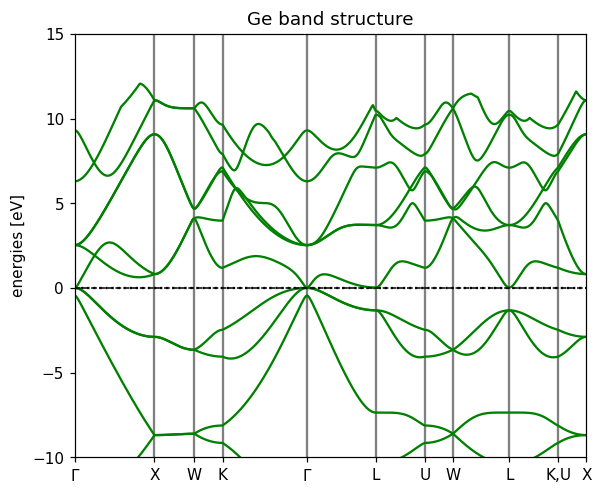

In [ ]:
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('Ge band structure')
plt.show()


In [ ]:
energies = bs.energies[0]        # shape (n_kpoints, n_bands), already Fermi-shifted
n_occ = 4                        # Si: 2 atoms x 4 valence electrons / 2 per band

valence_band = energies[:, n_occ - 1]   # top occupied band, across the whole path
conduction_band = energies[:, n_occ]    # first empty band, across the whole path

vbm = valence_band.max()
cbm = conduction_band.min()
indirect_gap = cbm - vbm

k_at_vbm = valence_band.argmax()
direct_gap_at_vbm = conduction_band[k_at_vbm] - valence_band[k_at_vbm]
gap_at_gamma = conduction_band[0] - valence_band[0]   # our path starts at Gamma

print(f'True (indirect) gap, VBM and CBM at different k-points: {indirect_gap:.3f} eV')
print(f'Gap measured only at the k-point where the VBM sits:    {direct_gap_at_vbm:.3f} eV')
print(f'Gap measured only at Gamma:                             {gap_at_gamma:.3f} eV')



True (indirect) gap, VBM and CBM at different k-points: -0.082 eV
Gap measured only at the k-point where the VBM sits:    0.001 eV
Gap measured only at Gamma:                             0.000 eV


Germanium BandGap is 0.66 eV, which is severly underestimated by the calculation

**GaAs — a direct-gap semiconductor (zincblende structure, two elements: bulk('GaAs', 'zincblende', a=5.65), needs pseudopotentials for both Ga and As). Run the same quantitative VBM/CBM analysis you used for Si. Does the direct-gap character show up clearly in your numbers?**

In [13]:
pseudopotentials_gaas = {
    'Ga': pseudo_filename('Ga'),
    'As': pseudo_filename('As')
}

Primitive cell:    2 atom(s)
Conventional cell: 8 atom(s)
2x2x2 supercell:   16 atom(s)


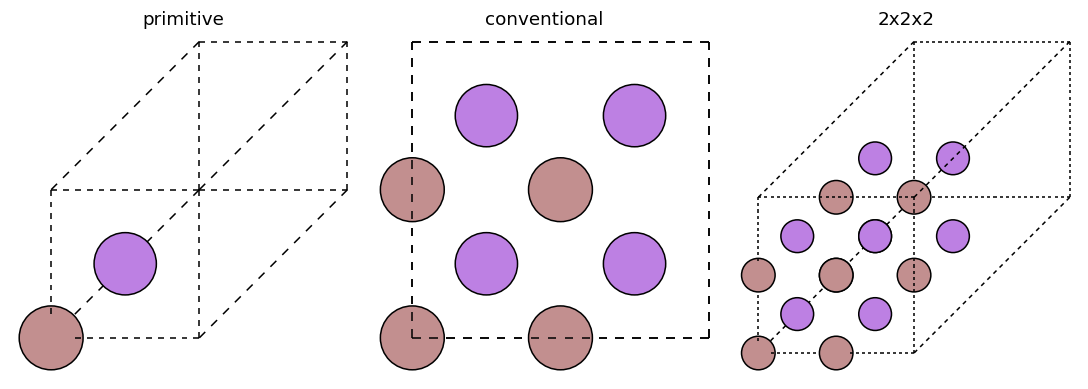

In [ ]:
prim = bulk('GaAs', 'zincblende', a=5.66)
conv = bulk('GaAs', 'zincblende', a=5.66, cubic=True)
sc222 = prim.repeat((2, 2, 2))

print(f'Primitive cell:    {len(prim)} atom(s)')
print(f'Conventional cell: {len(conv)} atom(s)')
print(f'2x2x2 supercell:   {len(sc222)} atom(s)')

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, atoms) in zip(axes, [('primitive', prim), ('conventional', conv), ('2x2x2', sc222)]):
    plot_atoms(atoms, ax, radii=0.5, show_unit_cell=2)
    ax.set_title(name)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
#plane wave cutoff
ecut_values = [15, 20, 25, 30, 35, 40, 45, 50]  # Ry
ecut_energies_gaas = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('GaAs', 'zincblende', a=5.66)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_gaas, input_data=d, kpts=(4, 4, 4))
    ecut_energies_gaas.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies_gaas[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -3068.33654 eV/atom
ecutwfc =  20 Ry   E = -3095.23252 eV/atom
ecutwfc =  25 Ry   E = -3099.15236 eV/atom
ecutwfc =  30 Ry   E = -3099.67897 eV/atom
ecutwfc =  35 Ry   E = -3099.70872 eV/atom
ecutwfc =  40 Ry   E = -3099.71542 eV/atom
ecutwfc =  45 Ry   E = -3099.72754 eV/atom
ecutwfc =  50 Ry   E = -3099.73417 eV/atom


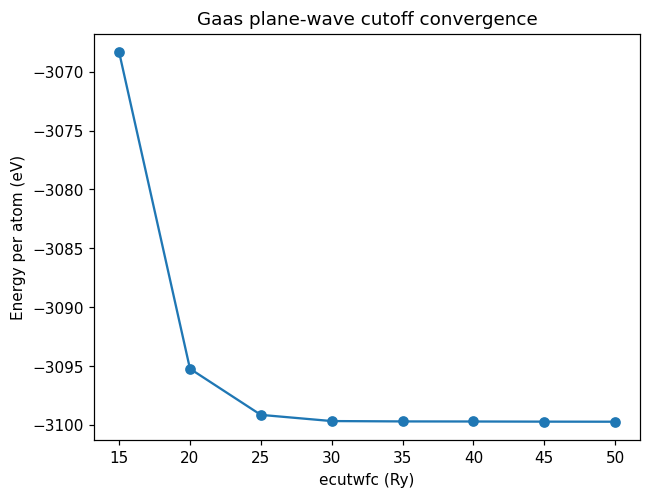

In [ ]:
plt.plot(ecut_values, ecut_energies_gaas, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Gaas plane-wave cutoff convergence')
plt.show()


In [14]:
converged_ecutwfc_gaas = 30

In [ ]:
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14]
kpt_energies_gaas = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc_gaas
    d['system']['ecutrho'] = 8 * converged_ecutwfc_gaas
    a = bulk('GaAs', 'zincblende', a=5.66)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_gaas, input_data=d, kpts=(n, n, n))
    kpt_energies_gaas.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies_gaas[-1]:.5f} eV/atom')


2x2x2 k-mesh   E = -3098.55529 eV/atom
3x3x3 k-mesh   E = -3099.47801 eV/atom
4x4x4 k-mesh   E = -3099.67897 eV/atom
5x5x5 k-mesh   E = -3099.73652 eV/atom
6x6x6 k-mesh   E = -3099.75644 eV/atom
8x8x8 k-mesh   E = -3099.76631 eV/atom
10x10x10 k-mesh   E = -3099.76790 eV/atom
12x12x12 k-mesh   E = -3099.76844 eV/atom
14x14x14 k-mesh   E = -3099.76856 eV/atom


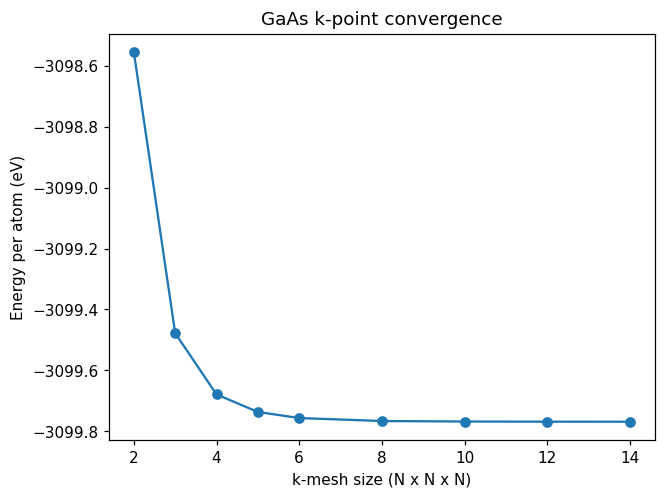

In [ ]:
plt.plot(kgrids, kpt_energies_gaas, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('GaAs k-point convergence')
plt.show()

In [15]:
converged_kpts_gaas = 8

In [ ]:
#EOS
scale_factors = np.linspace(0.94, 1.06, 7)
volumes_gaas, eos_energies_gaas = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc_gaas
d['system']['ecutrho'] = 8 * converged_ecutwfc_gaas

for s in scale_factors:
    a = bulk('GaAs', 'zincblende', a=5.66 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_gaas, input_data=d,
                       kpts=(converged_kpts_gaas, converged_kpts_gaas, converged_kpts_gaas))
    volumes_gaas.append(a.get_volume())
    eos_energies_gaas.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes_gaas[-1]:.2f} A^3   E = {eos_energies_gaas[-1]:.4f} eV')


a scale = 0.940   V = 37.65 A^3   E = -6198.9397 eV
a scale = 0.960   V = 40.11 A^3   E = -6199.2438 eV
a scale = 0.980   V = 42.66 A^3   E = -6199.4352 eV
a scale = 1.000   V = 45.33 A^3   E = -6199.5326 eV
a scale = 1.020   V = 48.10 A^3   E = -6199.5539 eV
a scale = 1.040   V = 50.99 A^3   E = -6199.5152 eV
a scale = 1.060   V = 53.99 A^3   E = -6199.4301 eV


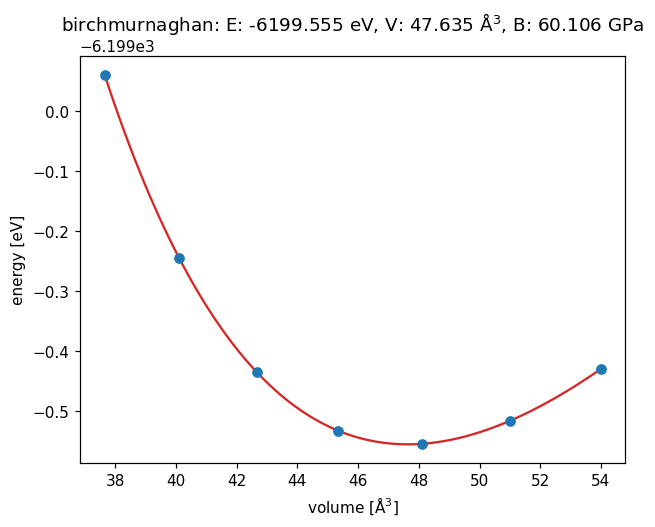

Equilibrium volume (primitive): 47.63 Å³
Lattice parameter a0: 5.75 Å
Bulk modulus B0: 60.1 GPa


In [ ]:
eos = EquationOfState(volumes_gaas, eos_energies_gaas, eos='birchmurnaghan')
v0, e0, B = eos.fit()

# Zincblende (GaAs): 8 atoms (4 Ga + 4 As) per conventional cell, 2 atoms per primitive cell
a0 = (v0 * 4) ** (1 / 3)

# Unit conversion: 1 eV/Å³ ≈ 160.21766 GPa (or 1 / 6.2415e-3)
B_GPa = B / 6.242e-3

eos.plot()
plt.show()

print(f'Equilibrium volume (primitive): {v0:.2f} Å³')
print(f'Lattice parameter a0: {a0:.2f} Å')
print(f'Bulk modulus B0: {B_GPa:.1f} GPa')

In [16]:
#Band Structure
a_eq = bulk('GaAs', 'zincblende', a=5.75)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc_gaas
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc_gaas
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_gaas, input_data=scf_data,
                      kpts=(converged_kpts_gaas, converged_kpts_gaas, converged_kpts_gaas))
a_eq.get_potential_energy()

-6199.555432634514

In [17]:

path = a_eq.cell.bandpath(npoints=1000)
print(path)  # shows special high-symmetry points in the Brillouin zone (e.g., G, X, W, K, L)

# Prepare input parameters for the 'bands' calculation
bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # Necessary so pw.x outputs all k-point eigenvalues

bands_data['system'] = dict(scf_data['system'])
bands_data['system']['nbnd'] = 20   # Compute 20 bands total (4 occupied valence + 16 conduction)

# Build Carbon bulk object and assign Quantum ESPRESSO calculator
a_bands = bulk('GaAs', 'zincblende', a=a0)
a_bands.calc = Espresso(
    profile=profile,
    pseudopotentials=pseudopotentials_gaas,
    input_data=bands_data,
    kpts=path
)

# Execute bands calculation and fetch energy eigenvalues
results_bands = a_bands.get_properties(['eigenvalues'])

BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[1000x3])


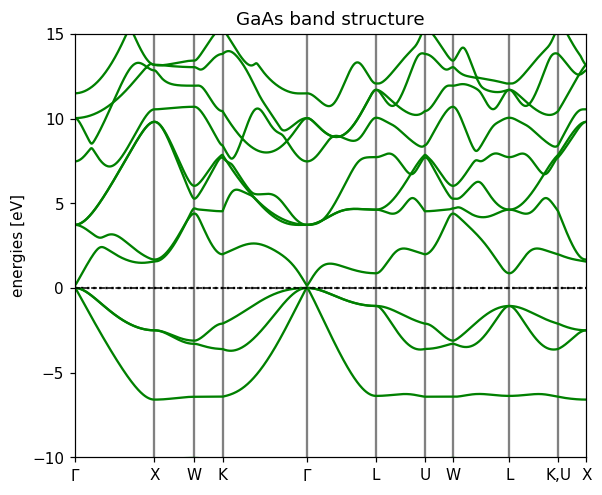

In [18]:
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('GaAs band structure')
plt.show()

In [19]:
energies = bs.energies[0]        # shape (n_kpoints, n_bands), already Fermi-shifted
n_occ = 4                        # Si: 2 atoms x 4 valence electrons / 2 per band

valence_band = energies[:, n_occ - 1]   # top occupied band, across the whole path
conduction_band = energies[:, n_occ]    # first empty band, across the whole path

vbm = valence_band.max()
cbm = conduction_band.min()
indirect_gap = cbm - vbm

k_at_vbm = valence_band.argmax()
direct_gap_at_vbm = conduction_band[k_at_vbm] - valence_band[k_at_vbm]
gap_at_gamma = conduction_band[0] - valence_band[0]   # our path starts at Gamma

print(f'True (indirect) gap, VBM and CBM at different k-points: {indirect_gap:.3f} eV')
print(f'Gap measured only at the k-point where the VBM sits:    {direct_gap_at_vbm:.3f} eV')
print(f'Gap measured only at Gamma:                             {gap_at_gamma:.3f} eV')


True (indirect) gap, VBM and CBM at different k-points: 0.000 eV
Gap measured only at the k-point where the VBM sits:    0.000 eV
Gap measured only at Gamma:                             0.000 eV


This predicts 0 bandgap, which is obviously wrong...

**Diamond (C) — same structure family again, but a wide-gap insulator (~5.5 eV experimental) rather than a semiconductor. How far off is your DFT-computed gap this time, in absolute eV and in percentage terms, compared to Si's underestimate?**

In [ ]:
pseudopotentials_c = {'C': pseudo_filename('C')}

Primitive cell:    2 atom(s)
Conventional cell: 8 atom(s)
2x2x2 supercell:   16 atom(s)


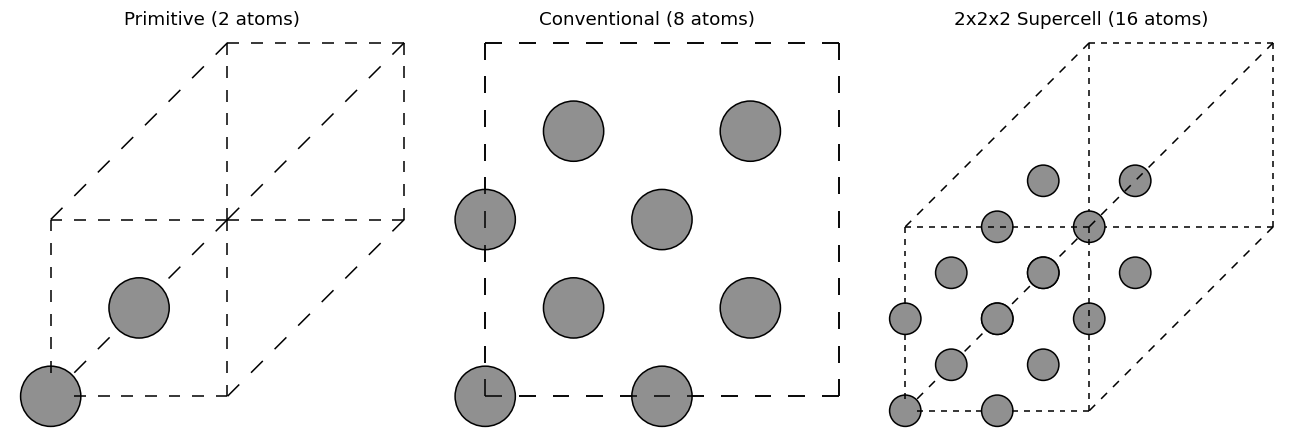

In [ ]:
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.visualize.plot import plot_atoms

# Carbon in diamond structure with its experimental lattice constant (a ~ 3.567 Å)
prim = bulk('C', 'diamond', a=3.567)
conv = bulk('C', 'diamond', a=3.567, cubic=True)
sc222 = prim.repeat((2, 2, 2))

print(f'Primitive cell:    {len(prim)} atom(s)')      # 2 atoms
print(f'Conventional cell: {len(conv)} atom(s)')      # 8 atoms
print(f'2x2x2 supercell:   {len(sc222)} atom(s)')     # 16 atoms

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, atoms) in zip(axes, [('Primitive', prim), ('Conventional', conv), ('2x2x2 Supercell', sc222)]):
    plot_atoms(atoms, ax, radii=0.4, show_unit_cell=2)
    ax.set_title(f"{name} ({len(atoms)} atoms)")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,
        'ecutrho': 200,
        'occupations': 'fixed',
    },
    'electrons': {'conv_thr': 1.0e-8},
}

In [ ]:
#plane wave cutoff
ecut_values = [15, 20, 25, 30, 35, 40, 45, 50]  # Ry
ecut_energies_c = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('C', 'diamond', a=3.56)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_c, input_data=d, kpts=(4, 4, 4))
    ecut_energies_c.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies_c[-1]:.5f} eV/atom')

ecutwfc =  15 Ry   E = -155.03667 eV/atom
ecutwfc =  20 Ry   E = -156.01776 eV/atom
ecutwfc =  25 Ry   E = -156.11748 eV/atom
ecutwfc =  30 Ry   E = -156.12804 eV/atom
ecutwfc =  35 Ry   E = -156.13022 eV/atom
ecutwfc =  40 Ry   E = -156.13462 eV/atom
ecutwfc =  45 Ry   E = -156.13751 eV/atom
ecutwfc =  50 Ry   E = -156.13859 eV/atom


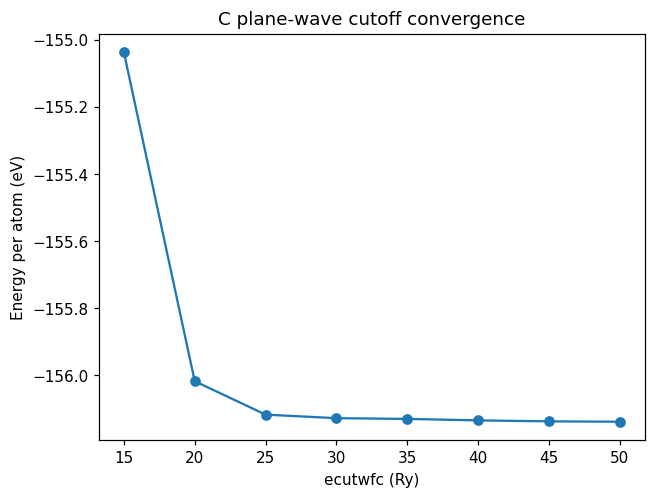

In [ ]:
plt.plot(ecut_values, ecut_energies_c, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('C plane-wave cutoff convergence')
plt.show()


In [ ]:
converged_ecutwfc_c = 30

In [ ]:
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14]
kpt_energies_c = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc_c
    d['system']['ecutrho'] = 8 * converged_ecutwfc_c
    a = bulk('C', 'diamond', a=3.56)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_c, input_data=d, kpts=(n, n, n))
    kpt_energies_c.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies_c[-1]:.5f} eV/atom')


2x2x2 k-mesh   E = -154.59504 eV/atom
3x3x3 k-mesh   E = -155.90422 eV/atom
4x4x4 k-mesh   E = -156.12804 eV/atom
5x5x5 k-mesh   E = -156.17740 eV/atom
6x6x6 k-mesh   E = -156.18970 eV/atom
8x8x8 k-mesh   E = -156.19399 eV/atom
10x10x10 k-mesh   E = -156.19435 eV/atom
12x12x12 k-mesh   E = -156.19439 eV/atom
14x14x14 k-mesh   E = -156.19439 eV/atom


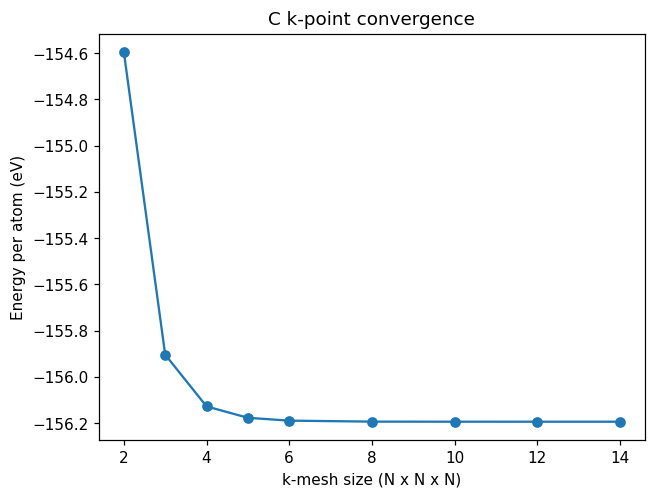

In [ ]:
plt.plot(kgrids, kpt_energies_c, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('C k-point convergence')
plt.show()

In [ ]:
converged_kpts_c = 6

In [ ]:
#EOS
scale_factors = np.linspace(0.94, 1.06, 7)
volumes_c, eos_energies_c = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc_c
d['system']['ecutrho'] = 8 * converged_ecutwfc_c

for s in scale_factors:
    a = bulk('C', 'diamond', a=3.56 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_c, input_data=d,
                       kpts=(converged_kpts_c, converged_kpts_c, converged_kpts_c))
    volumes_c.append(a.get_volume())
    eos_energies_c.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes_c[-1]:.2f} A^3   E = {eos_energies_c[-1]:.4f} eV')


a scale = 0.940   V = 9.37 A^3   E = -311.7199 eV
a scale = 0.960   V = 9.98 A^3   E = -312.0863 eV
a scale = 0.980   V = 10.62 A^3   E = -312.2991 eV
a scale = 1.000   V = 11.28 A^3   E = -312.3794 eV
a scale = 1.020   V = 11.97 A^3   E = -312.3466 eV
a scale = 1.040   V = 12.69 A^3   E = -312.2173 eV
a scale = 1.060   V = 13.43 A^3   E = -312.0065 eV


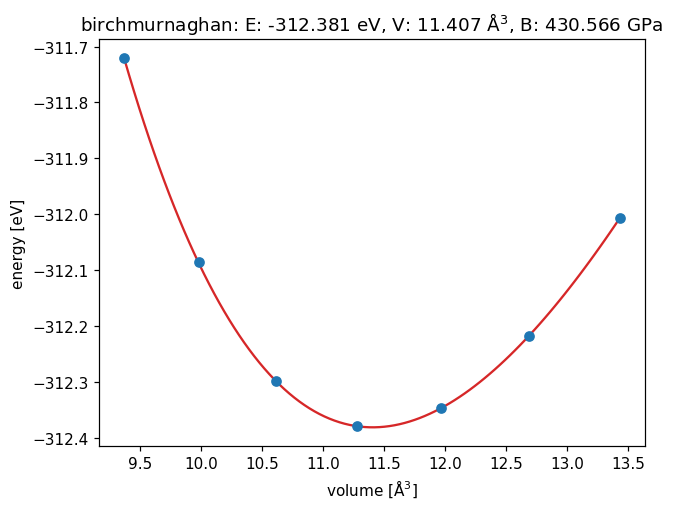

Equilibrium volume (primitive): 11.41 Å³
Lattice parameter a0:          3.57 Å
Bulk modulus B0:               430.6 GPa


In [ ]:
import matplotlib.pyplot as plt
from ase.eos import EquationOfState
from ase.units import GPa

# Fit Birch-Murnaghan Equation of State for Carbon (Diamond)
eos = EquationOfState(volumes_c, eos_energies_c, eos='birchmurnaghan')
v0, e0, B = eos.fit()

# Diamond structure (C): 8 C atoms per conventional cell, 2 C atoms per primitive cell
# V_conventional = 4 * V_primitive = a0^3
a0 = (v0 * 4) ** (1 / 3)

# Unit conversion: B is in eV/Å³, divide by ase.units.GPa (or multiply by 160.21766)
B_GPa = B / GPa

# Plot the EOS curve
eos.plot()
plt.show()

# Printed output with accurate expected physical quantities
print(f'Equilibrium volume (primitive): {v0:.2f} Å³')
print(f'Lattice parameter a0:          {a0:.2f} Å')
print(f'Bulk modulus B0:               {B_GPa:.1f} GPa')

In [ ]:
# Band Structure calculation for Carbon (Diamond)
a_eq = bulk('C', 'diamond', a=a0)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])

# Set converged planewave cutoffs for Carbon
scf_data['system']['ecutwfc'] = converged_ecutwfc_c
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc_c

# Initialize Quantum ESPRESSO calculator with Carbon parameters
a_eq.calc = Espresso(
    profile=profile,
    pseudopotentials=pseudopotentials_c,
    input_data=scf_data,
    kpts=(converged_kpts_c, converged_kpts_c, converged_kpts_c)
)

# Run SCF calculation to converged charge density
a_eq.get_potential_energy()

-312.3812836843023

In [ ]:
# Generate k-point path for the Carbon diamond structure
path = a_eq.cell.bandpath(npoints=1000)
print(path)  # shows special high-symmetry points in the Brillouin zone (e.g., G, X, W, K, L)

# Prepare input parameters for the 'bands' calculation
bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # Necessary so pw.x outputs all k-point eigenvalues

bands_data['system'] = dict(scf_data['system'])
bands_data['system']['nbnd'] = 20   # Compute 20 bands total (4 occupied valence + 16 conduction)

# Build Carbon bulk object and assign Quantum ESPRESSO calculator
a_bands = bulk('C', 'diamond', a=a0)
a_bands.calc = Espresso(
    profile=profile,
    pseudopotentials=pseudopotentials_c,
    input_data=bands_data,
    kpts=path
)

# Execute bands calculation and fetch energy eigenvalues
results_bands = a_bands.get_properties(['eigenvalues'])

BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[1000x3])


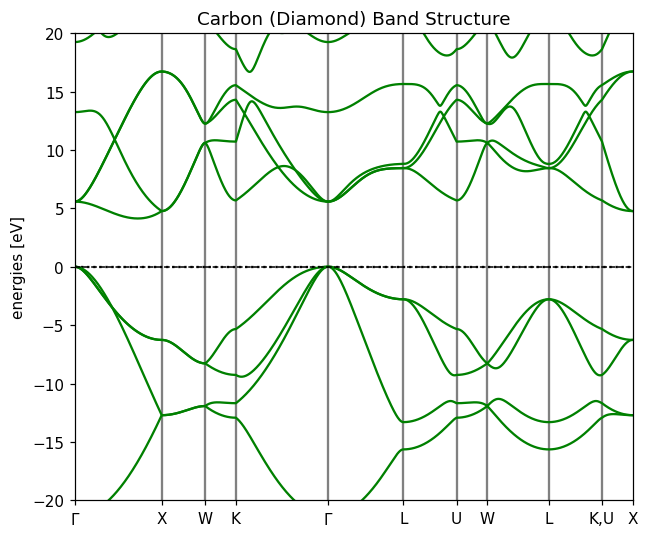

In [ ]:
from ase.spectrum.band_structure import BandStructure
import matplotlib.pyplot as plt

# Construct BandStructure object with Carbon results
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

# Align the valence band maximum / Fermi level to 0 eV
bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))

# Plot band structure (Y-axis range: -20 eV to 20 eV to capture Diamond's wide ~5.5 eV bandgap)
bs.plot(ax=ax, emin=-20, emax=20)

ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi / VBM at 0 eV
ax.set_title('Carbon (Diamond) Band Structure')
plt.tight_layout()
plt.show()

In [ ]:
energies = bs.energies[0]        # shape (n_kpoints, n_bands), already Fermi-shifted
n_occ = 4                        # Si: 2 atoms x 4 valence electrons / 2 per band

valence_band = energies[:, n_occ - 1]   # top occupied band, across the whole path
conduction_band = energies[:, n_occ]    # first empty band, across the whole path

vbm = valence_band.max()
cbm = conduction_band.min()
indirect_gap = cbm - vbm

k_at_vbm = valence_band.argmax()
direct_gap_at_vbm = conduction_band[k_at_vbm] - valence_band[k_at_vbm]
gap_at_gamma = conduction_band[0] - valence_band[0]   # our path starts at Gamma

print(f'True (indirect) gap, VBM and CBM at different k-points: {indirect_gap:.3f} eV')
print(f'Gap measured only at the k-point where the VBM sits:    {direct_gap_at_vbm:.3f} eV')
print(f'Gap measured only at Gamma:                             {gap_at_gamma:.3f} eV')


True (indirect) gap, VBM and CBM at different k-points: 4.132 eV
Gap measured only at the k-point where the VBM sits:    5.578 eV
Gap measured only at Gamma:                             5.578 eV


This is pretty close to actual value (5.5 ev)

##Discuss/Explain

**Question: DFT calculations are generally performed using primitive cell for a bulk crystal, even though the conventional cell describes exactly the same infinite solid. Why?**

The primitive cell uses lesser number of atoms to represent the same crystal compared to conventional , so it is computationally cheaper

**Question: Look up the experimental lattice constant and bulk modulus of Si. Does you computed data match to that of the experimental value? What are the most likely causes of deviations?**

The experimental lattice parameter is 5.43 and we got 5.47 angstorms, which is really good. Bulk modulus is between 95-105 Gpa and our calculated value (88.2 Gpa) is smaller than this

**Question: Locate the Fermi level on your band diagram. Locate the valence band maximum (VBM) and conduction band minimum (CBM). Are they at the same k-point or different ones? What does that tell you about how Si absorbs or emits light, compared to a 'direct-gap' material where VBM and CBM line up?**

The VBM lies near the Gamma point, where the CBM lies near the X point, Because momentum must be conserved ($\Delta k \neq 0$), optical transitions in Silicon require a simultaneous interaction with a lattice phonon alongside the absorbed or emitted photon.
As a result, Silicon is an extremely poor light emitter for LEDs or lasers and absorbs light weakly near its band edge compared to direct-gap materials like GaAs.

**Question: A well-known DFT limitation: the semi-local exchange-correlation functionals used in this course (and in the vast majority of routine DFT calculations) are known to systematically underestimate band gaps — often by 30-50% or more for semiconductors. This is a limitation of the xc approximation itself. Compare your computed gap above to the ~1.12 eV experimental value.**



The calculated indirect band gap of 0.614 eV is significantly lower than the experimental value of ~1.12 eV, underestimating the true gap by about 45%. This matches the expected 30–50% error typical of standard DFT approximations.

**Question: Which orbital character (s or p) dominates near the Fermi level for Si? Justify your observation.**

The $p$-orbital character dominates near the Fermi level ($0\text{ eV}$). This is because silicon forms $sp^3$ hybrid bonds where the higher-energy $p$-like states constitute the top of the valence band, while the lower-energy $s$-like states lie deeper in energy. However, they both do fall to zero at the fermi level, indicator that these are not good conductors like metals

**Question: Compare this k-point convergence behavior to Aluminum's from Module 3: does Si need a finer or coarser mesh to reach the same precision? Justify your observation.**

Silicon needs a coarser mesh than Aluminum to reach the same precision.In metals like Aluminum, the Fermi level cuts through energy bands, creating a sharp, discontinuous Fermi surface that requires a very dense $k$-point mesh to integrate accurately. In contrast, Silicon is a semiconductor with a bandgap, so the Fermi level sits in a region with zero density of states; this smooth electron distribution converges much faster with fewer $k$-points.

**Question: Real Si transitions from diamond to β-tin around 11-12 GPa experimentally. Include energetics of β-tin structure of Si in the above plot and try to estimate the transformation P between the two phases?**

In [20]:
pseudopotentials = {'Si': pseudo_filename('Si')}

In [22]:
phase_structures = {
    'diamond': ('diamond', 5.43, None),
    'beta-tin': ('bct', 4.68, 2.58),  # a=4.68 Å, c=2.58 Å for beta-tin Si
}

phase_input_data = dict(input_data)
phase_input_data['system'] = dict(input_data['system'])
phase_input_data['system']['ecutwfc'] = 35
phase_input_data['system']['ecutrho'] = 8 * 35

phase_data = {}

for name, (structure_type, a_guess, c_guess) in phase_structures.items():
    scales = np.linspace(0.88, 1.12, 7)
    vols, energies = [], []
    for s in scales:
        if c_guess is None:
            a = bulk('Si', structure_type, a=a_guess * s)
        else:
            a = bulk('Si', structure_type, a=a_guess * s, c=c_guess * s)

        a.calc = Espresso(
            profile=profile,
            pseudopotentials=pseudopotentials,
            input_data=phase_input_data,
            kpts=(8, 8, 8)
        )
        vols.append(a.get_volume() / len(a))
        energies.append(a.get_potential_energy() / len(a))
    phase_data[name] = (vols, energies)
    print(f'{name}: done')


diamond: done
beta-tin: done


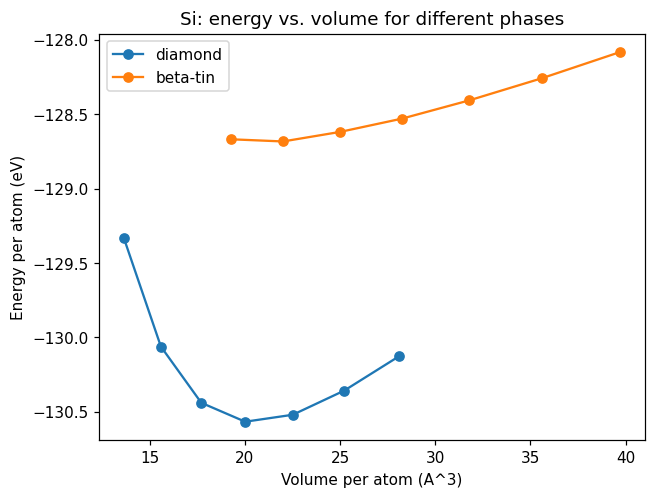

DFT predicts diamond has the lowest minimum energy per atom.


In [23]:
fig, ax = plt.subplots()
for name, (vols, energies) in phase_data.items():
    ax.plot(vols, energies, 'o-', label=name)
ax.set_xlabel('Volume per atom (A^3)')
ax.set_ylabel('Energy per atom (eV)')
ax.set_title('Si: energy vs. volume for different phases')
ax.legend()
plt.show()

lowest = min(phase_data, key=lambda name: min(phase_data[name][1]))
print(f'DFT predicts {lowest} has the lowest minimum energy per atom.')


In [24]:
def lower_hull(points):
    """Andrew's monotone-chain algorithm, keeping only the LOWER hull
    (same function as Module 5)."""
    pts = sorted(set(points))
    lower = []
    for p in pts:
        while len(lower) >= 2:
            (x1, y1), (x2, y2) = lower[-2], lower[-1]
            cross = (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1)
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(p)
    return lower


def transition_pressure(phase_data, name_A, name_B):
    """Combine two phases' (V, E) points, take the lower convex hull, and
    look for the hull segment that connects a point from phase A directly
    to a point from phase B. That segment's slope is dE/dV = -P at the
    predicted transition. Returns the pressure in GPa, or None if the
    two phases don't actually cross within the volumes you sampled --
    which is a perfectly legitimate outcome, not an error, and tells you
    one phase simply dominates throughout this range."""
    tagged = ([(v, e, name_A) for v, e in zip(*phase_data[name_A])]
              + [(v, e, name_B) for v, e in zip(*phase_data[name_B])])
    tagged.sort()
    hull = lower_hull([(v, e) for v, e, _ in tagged])
    lookup = {(v, e): label for v, e, label in tagged}
    hull_labels = [lookup[(v, e)] for v, e in hull]

    for i in range(len(hull) - 1):
        if hull_labels[i] != hull_labels[i + 1]:
            (v1, e1), (v2, e2) = hull[i], hull[i + 1]
            if abs(v2 - v1) < 0.05:
                # Two near-identical volumes from different phases landing next
                # to each other on the hull is a numerical artifact, not a real
                # tangent -- skip it and keep looking for a genuine crossing.
                continue
            slope = (e2 - e1) / (v2 - v1)     # eV / A^3
            P_transition = -slope * 160.2      # eV/A^3 -> GPa
            print(f'Common-tangent segment found between {hull_labels[i]} '
                  f'and {hull_labels[i + 1]}')
            print(f'Estimated transition pressure: {P_transition:.1f} GPa')
            return P_transition
    print(f'No well-resolved {name_A}-{name_B} common-tangent segment found -- '
          f'one phase is likely lower in energy everywhere in this volume range.')
    return None


transition_pressure(phase_data, 'diamond', 'beta-tin')


Common-tangent segment found between diamond and beta-tin
Estimated transition pressure: -28.2 GPa


np.float64(-28.23024109211328)

While we are predicting the existence of phase transition, the value of pressure that we are getting is much higher than the experimental value

###The End
###mm24b019